# Heart Disease Risk Analysis

## Exploratory Data Analysis of Cardiovascular Risk Factors

### Author
**Kaushik Sahu**  
B.Tech — Biomedical Engineering  
National Institute of Technology (NIT) Rourkela

---

## Project Objective

This project performs exploratory data analysis (EDA) on a simulated cardiovascular disease dataset to identify the strongest predictors of heart disease using statistical analysis, feature engineering, and healthcare-oriented storytelling.

The analysis investigates demographic, physiological, and ECG-related variables associated with cardiovascular disease prevalence.

---

## Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Jupyter Notebook

---

## Dataset Summary

- **Rows:** 918 patients
- **Columns:** 12 clinical variables
- **Target Variable:** `HeartDisease`
    - `1` = Disease Present
    - `0` = Healthy

---

## Analytical Goals

- Understand cardiovascular risk distribution
- Identify strongest disease predictors
- Compare healthy vs diseased populations
- Evaluate cumulative clinical risk burden
- Apply statistical validation techniques
- Build recruiter-ready healthcare analytics storytelling

# Step 1 — Environment Setup

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)

# Color palette
BG_COLOR      = "#0A0E1A"
AX_COLOR      = "#111827"
TEXT_COLOR    = "#F0F4FF"
MUTED_TEXT    = "#8892A4"
GRID_COLOR    = "#253047"
HEALTHY_COLOR = "#2ECC71"
DISEASE_COLOR = "#E74C3C"
ACCENT_COLOR  = "#3498DB"

# Matplotlib global theme 
plt.rcParams.update({
    "figure.facecolor":  BG_COLOR,
    "figure.figsize":    (10, 6),
    "axes.facecolor":    AX_COLOR,
    "axes.edgecolor":    MUTED_TEXT,
    "axes.labelcolor":   TEXT_COLOR,
    "axes.titlecolor":   TEXT_COLOR,
    "text.color":        TEXT_COLOR,
    "xtick.color":       TEXT_COLOR,   # ← fixed: was MUTED_TEXT
    "ytick.color":       TEXT_COLOR,   # ← fixed: was MUTED_TEXT
    "font.family":       "DejaVu Sans",
    "grid.color":        GRID_COLOR,
    "grid.linewidth":    0.5,
    "savefig.facecolor": BG_COLOR,
    "savefig.dpi":       150,
})

# Seaborn theme
sns.set_style("darkgrid", {
    "axes.facecolor":   AX_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor":   MUTED_TEXT,
    "grid.color":       GRID_COLOR,
    "text.color":       TEXT_COLOR,
    "xtick.color":      TEXT_COLOR,
    "ytick.color":      TEXT_COLOR,
})

plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["axes.labelsize"]  = 12

print("Project environment initialized successfully.")

Project environment initialized successfully.


# Step 2 — Data Loading & Understanding

In [2]:
# LOAD DATASET

df = pd.read_csv("../data/heart_disease_data.csv")

print("Dataset loaded successfully.")
print()

print("Dataset Shape:")
print(df.shape)

Dataset loaded successfully.

Dataset Shape:
(918, 12)


In [3]:
# PREVIEW DATA

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,58,Female,Atypical Angina,122,162,0,Normal,168,No,0.3,Flat,0
1,52,Male,Asymptomatic,101,322,1,Normal,159,No,2.4,Down,1
2,59,Male,Asymptomatic,111,226,0,Normal,144,No,0.5,Up,1
3,67,Female,Non-Anginal Pain,154,232,1,Normal,131,No,0.0,Up,0
4,51,Female,Asymptomatic,129,211,0,ST,171,Yes,0.4,Down,0


In [4]:
# DATASET STRUCTURE

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
# SUMMARY STATISTICS — NUMERICAL FEATURES

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.708061,8.735028,28.0,48.0,54.0,59.0,77.0
RestingBP,918.0,131.510893,17.679918,94.0,119.0,131.0,144.0,200.0
Cholesterol,918.0,242.515251,52.543976,126.0,206.0,242.0,274.0,412.0
FastingBS,918.0,0.197168,0.398077,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,166.178649,15.092687,123.0,156.0,166.0,176.0,202.0
Oldpeak,918.0,1.025817,1.037717,0.0,0.3,0.7,1.5,6.2
HeartDisease,918.0,0.477124,0.499749,0.0,0.0,0.0,1.0,1.0


In [6]:
# CATEGORICAL FEATURE OVERVIEW

categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Sex =====
Sex
Male      627
Female    291
Name: count, dtype: int64

===== ChestPainType =====
ChestPainType
Asymptomatic        429
Non-Anginal Pain    273
Atypical Angina     128
Typical Angina       88
Name: count, dtype: int64

===== RestingECG =====
RestingECG
Normal    579
LVH       172
ST        167
Name: count, dtype: int64

===== ExerciseAngina =====
ExerciseAngina
No     579
Yes    339
Name: count, dtype: int64

===== ST_Slope =====
ST_Slope
Flat    432
Up      299
Down    187
Name: count, dtype: int64


In [7]:
# MISSING VALUES CHECK

missing_values = df.isnull().sum()

print(missing_values)

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [8]:
# TARGET VARIABLE DISTRIBUTION

heart_disease_rate = df["HeartDisease"].mean()

print(f"Heart Disease Prevalence: {heart_disease_rate:.1%}")

df["HeartDisease"].value_counts()

Heart Disease Prevalence: 47.7%


HeartDisease
0    480
1    438
Name: count, dtype: int64

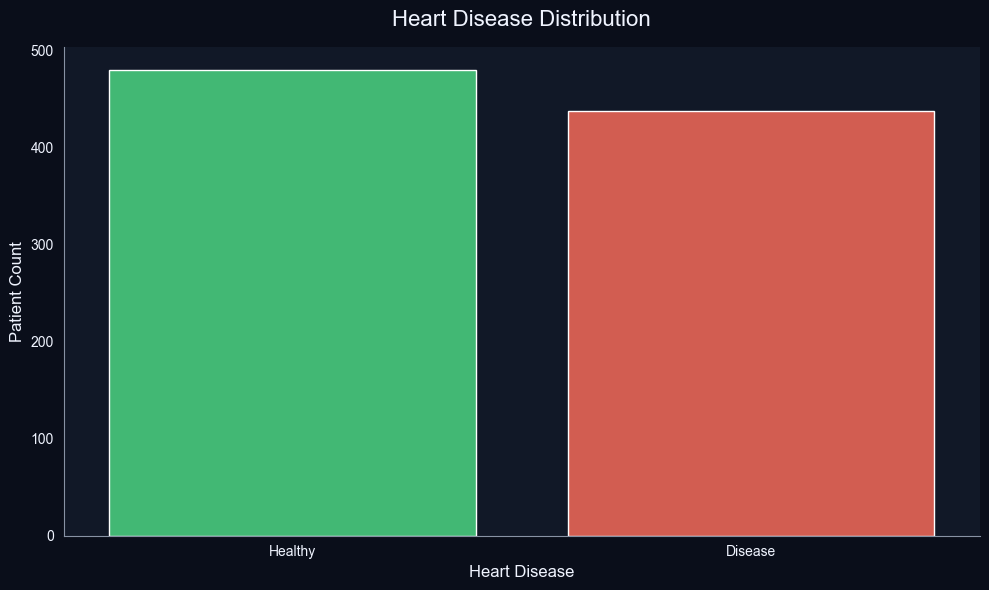

In [9]:
# HEART DISEASE DISTRIBUTION

fig, ax = plt.subplots()

sns.countplot(
    data=df,
    x="HeartDisease",
    hue="HeartDisease",
    palette=[HEALTHY_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

ax.set_title("Heart Disease Distribution", fontsize=16, pad=15)
ax.set_xlabel("Heart Disease")
ax.set_ylabel("Patient Count")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Healthy", "Disease"])

ax.grid(axis="y")

# Remove extra spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save figure
plt.savefig("../visuals/01_target_distribution.png")

plt.show()

# Step 3 — Feature Engineering

In [10]:
# VALIDATE NUMERICAL RANGES

numerical_cols = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

for col in numerical_cols:
    
    print(f"\n===== {col} =====")
    
    print(f"Minimum: {df[col].min()}")
    print(f"Maximum: {df[col].max()}")


===== Age =====
Minimum: 28
Maximum: 77

===== RestingBP =====
Minimum: 94
Maximum: 200

===== Cholesterol =====
Minimum: 126
Maximum: 412

===== MaxHR =====
Minimum: 123
Maximum: 202

===== Oldpeak =====
Minimum: 0.0
Maximum: 6.2


In [11]:
# BINARY ENCODING FOR ANALYSIS

df["Sex_encoded"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

df["ExerciseAngina_encoded"] = df["ExerciseAngina"].map({
    "No": 0,
    "Yes": 1
})

print("Binary encoding completed.")

Binary encoding completed.


In [12]:
# CREATE CLINICAL RISK FACTORS

df["Age_Risk"] = (df["Age"] > 55).astype(int)

df["BP_Risk"] = (df["RestingBP"] > 140).astype(int)

df["Cholesterol_Risk"] = (df["Cholesterol"] > 240).astype(int)

df["BloodSugar_Risk"] = df["FastingBS"]

df["ExerciseAngina_Risk"] = df["ExerciseAngina_encoded"]

df["Oldpeak_Risk"] = (df["Oldpeak"] > 2).astype(int)

df["ST_Slope_Risk"] = (df["ST_Slope"] == "Flat").astype(int)

print("Clinical risk indicators created.")

Clinical risk indicators created.


In [13]:
# CREATE COMPOSITE RISK SCORE

risk_columns = [
    "Age_Risk",
    "BP_Risk",
    "Cholesterol_Risk",
    "BloodSugar_Risk",
    "ExerciseAngina_Risk",
    "Oldpeak_Risk",
    "ST_Slope_Risk"
]

df["RiskFactorCount"] = df[risk_columns].sum(axis=1)

print("Composite risk score created.")

print()
print(df["RiskFactorCount"].value_counts().sort_index())

Composite risk score created.

RiskFactorCount
0     52
1    169
2    283
3    238
4    131
5     38
6      5
7      2
Name: count, dtype: int64


In [14]:
# PREVIEW ENGINEERED FEATURES

df[[
    "Age",
    "RestingBP",
    "Oldpeak",
    "ExerciseAngina",
    "RiskFactorCount",
    "HeartDisease"
]].head()

,Age,RestingBP,Oldpeak,ExerciseAngina,RiskFactorCount,HeartDisease
0,58,122,0.3,No,2,0
1,52,101,2.4,No,3,1
2,59,111,0.5,No,1,1
3,67,154,0.0,No,3,0
4,51,129,0.4,Yes,1,0


# Step 4 — Univariate Analysis

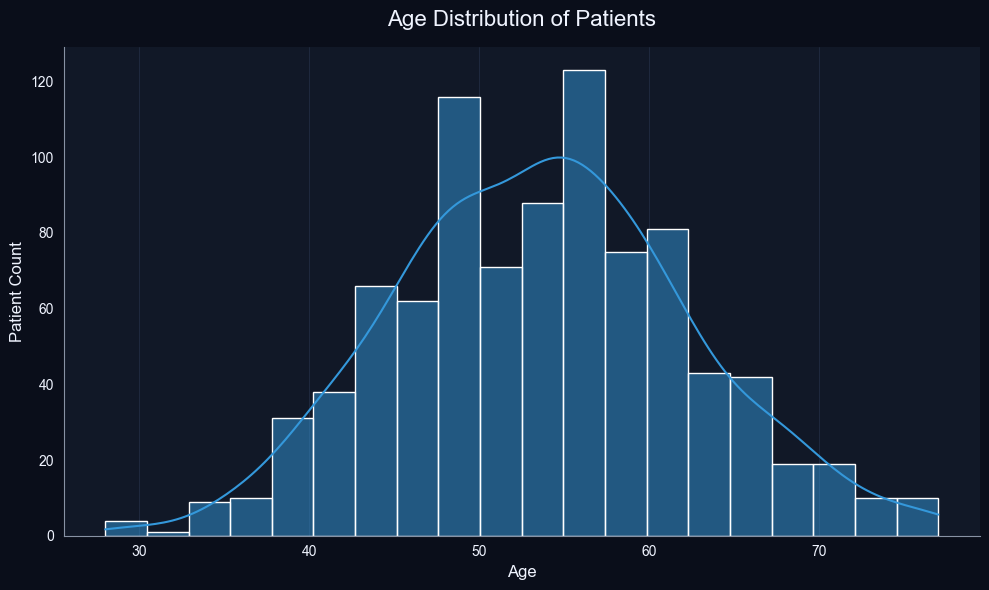

In [15]:
# AGE DISTRIBUTION

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color=ACCENT_COLOR,
    ax=ax
)

ax.set_title("Age Distribution of Patients", fontsize=16, pad=15)
ax.set_xlabel("Age")
ax.set_ylabel("Patient Count")

ax.grid(axis="y")

# Remove unnecessary spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/01_age_distribution.png")

plt.show()

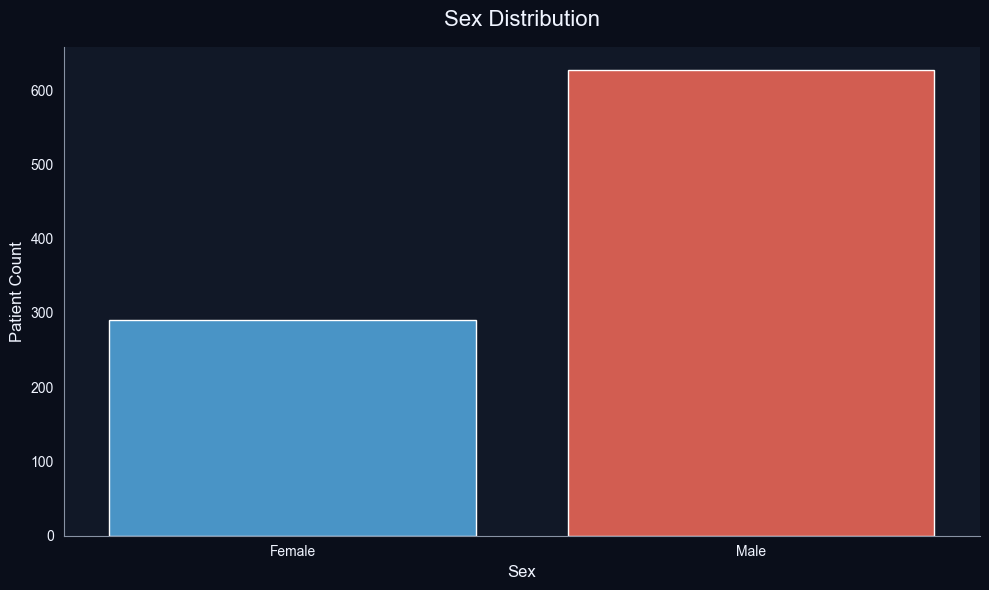

In [16]:
# SEX DISTRIBUTION

fig, ax = plt.subplots()

sns.countplot(
    data=df,
    x="Sex",
    hue="Sex",
    palette=[ACCENT_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

ax.set_title("Sex Distribution", fontsize=16, pad=15)
ax.set_xlabel("Sex")
ax.set_ylabel("Patient Count")

ax.grid(axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/01_sex_distribution.png")

plt.show()

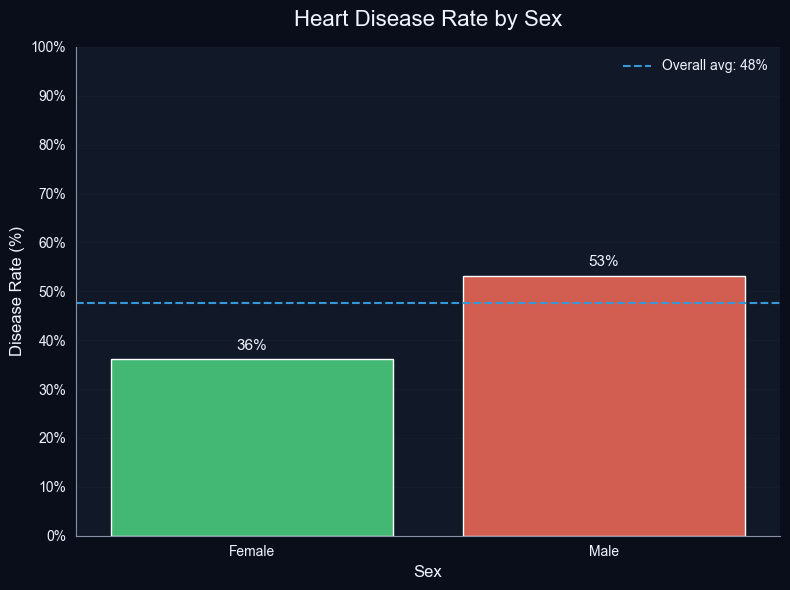

In [17]:
# HEART DISEASE RATE BY SEX

sex_risk = (
    df.groupby("Sex")["HeartDisease"]
    .mean()
    .reset_index()
)

overall_avg = df["HeartDisease"].mean()

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=sex_risk,
    x="Sex",
    y="HeartDisease",
    hue="Sex",
    palette=[HEALTHY_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

# Labels above bars
for i, val in enumerate(sex_risk["HeartDisease"]):
    ax.text(
        i,
        val + 0.02,
        f"{val:.0%}",
        ha="center",
        fontsize=11,
        color=TEXT_COLOR
    )

# Average line
ax.axhline(
    overall_avg,
    linestyle="--",
    linewidth=1.5,
    color=ACCENT_COLOR,
    label=f"Overall avg: {overall_avg:.0%}"
)

ax.legend(frameon=False)

# Titles and labels
ax.set_title("Heart Disease Rate by Sex", fontsize=16, pad=15)

ax.set_xlabel("Sex")
ax.set_ylabel("Disease Rate (%)")

# Percentage axis
ax.set_ylim(0, 1)

yticks = np.arange(0, 1.1, 0.1)

ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.0%}" for y in yticks])

# Grid
ax.grid(axis="y", alpha=0.3)

# Style cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/01_disease_rate_by_sex.png")

plt.show()

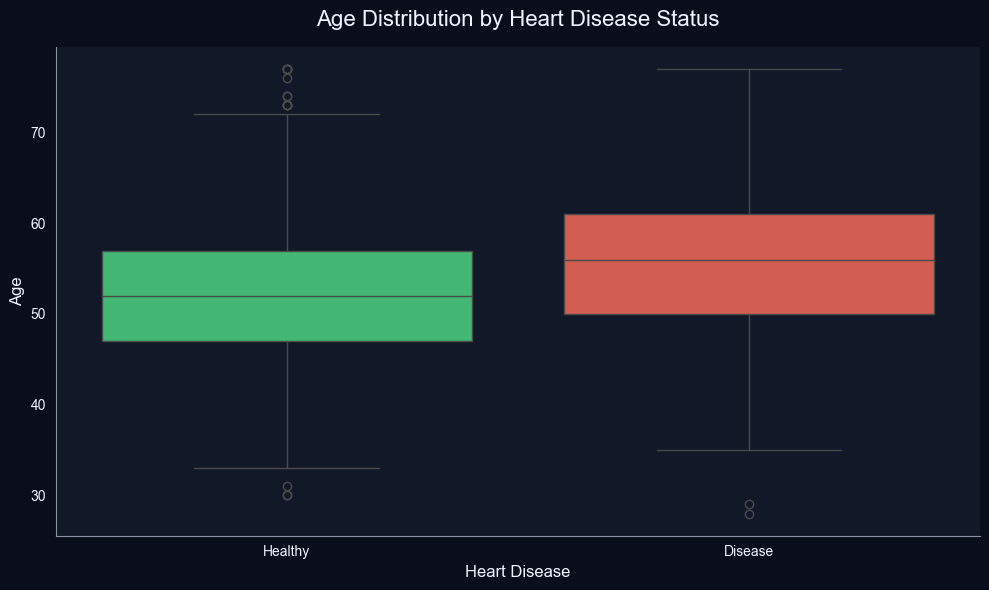

In [18]:
# AGE DISTRIBUTION BY HEART DISEASE

fig, ax = plt.subplots()

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Age",
    hue="HeartDisease",
    palette=[HEALTHY_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

ax.set_title("Age Distribution by Heart Disease Status", fontsize=16, pad=15)
ax.set_xlabel("Heart Disease")
ax.set_ylabel("Age")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Healthy", "Disease"])

ax.grid(axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/01_age_boxplot_by_disease.png")

plt.show()

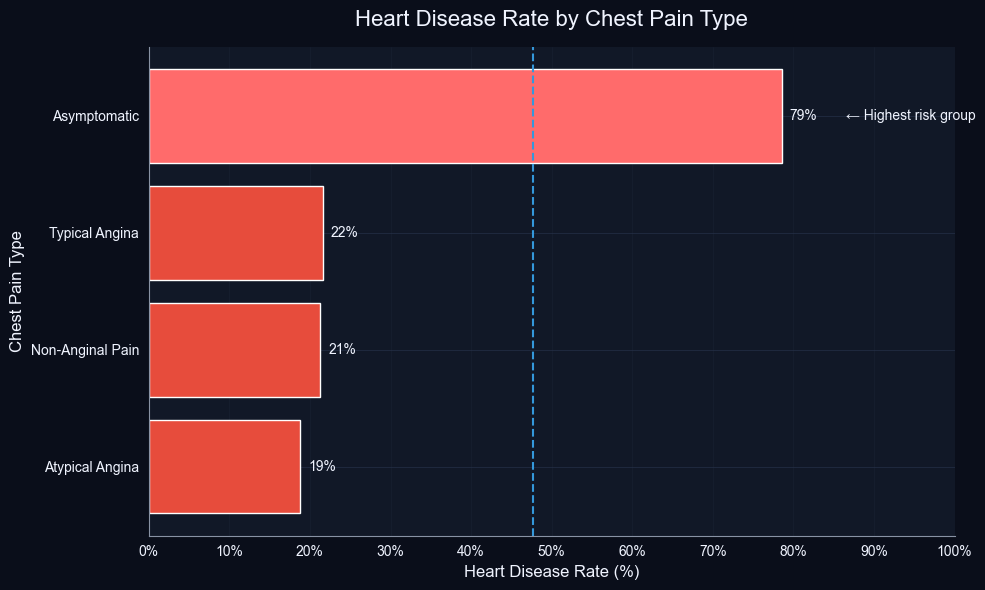

In [28]:
# HEART DISEASE RATE BY CHEST PAIN TYPE

cp_risk = (
    df.groupby("ChestPainType")["HeartDisease"]
    .mean()
    .sort_values(ascending=True)
)

overall_avg = df["HeartDisease"].mean()

# Custom colors
colors = [
    "#FF6B6B" if idx == "Asymptomatic" else DISEASE_COLOR
    for idx in cp_risk.index
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    cp_risk.index,
    cp_risk.values,
    color=colors
)

# Labels at end of bars
for bar, val in zip(bars, cp_risk.values):

    ax.text(
        val + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{val:.0%}",
        va="center",
        fontsize=10,
        color=TEXT_COLOR
    )

# Average line
ax.axvline(
    overall_avg,
    linestyle="--",
    linewidth=1.5,
    color=ACCENT_COLOR
)

# Highlight annotation
asym_index = list(cp_risk.index).index("Asymptomatic")

ax.text(
    cp_risk.loc["Asymptomatic"] + 0.08,
    asym_index,
    "← Highest risk group",
    va="center",
    fontsize=10,
    color=TEXT_COLOR
)

# Labels and title
ax.set_title(
    "Heart Disease Rate by Chest Pain Type",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Heart Disease Rate (%)")
ax.set_ylabel("Chest Pain Type")

# Percentage axis
xticks = np.arange(0, 1.1, 0.1)

ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.0%}" for x in xticks])

# Grid
ax.grid(axis="x", alpha=0.3)

# Style cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/02_chest_pain_vs_disease.png")

plt.show()

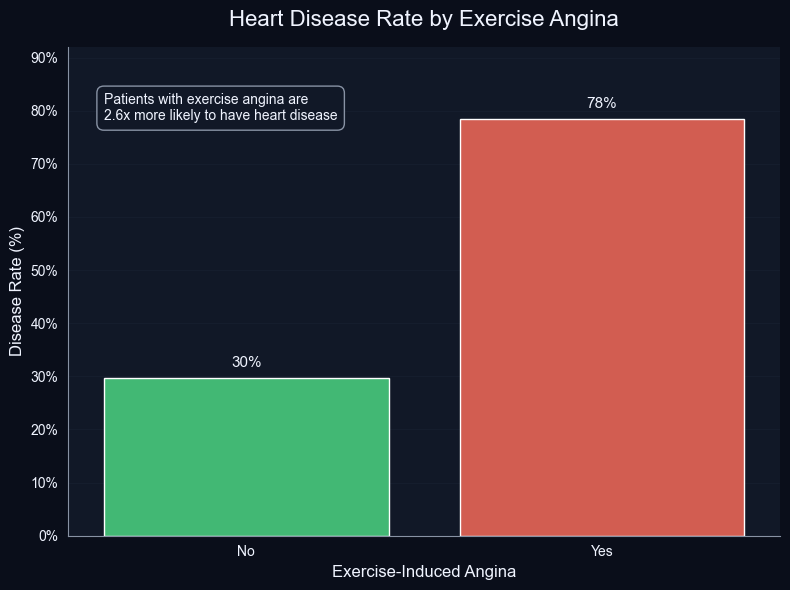

In [29]:
# HEART DISEASE RATE BY EXERCISE ANGINA

angina_risk = (
    df.groupby("ExerciseAngina")["HeartDisease"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=angina_risk,
    x="ExerciseAngina",
    y="HeartDisease",
    hue="ExerciseAngina",
    palette=[HEALTHY_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

# Labels above bars
for i, val in enumerate(angina_risk["HeartDisease"]):

    ax.text(
        i,
        val + 0.02,
        f"{val:.0%}",
        ha="center",
        fontsize=11,
        color=TEXT_COLOR
    )

# Insight text box
ax.text(
    0.05,
    0.85,
    "Patients with exercise angina are\n2.6x more likely to have heart disease",
    transform=ax.transAxes,
    fontsize=10,
    color=TEXT_COLOR,
    bbox=dict(
        facecolor=AX_COLOR,
        edgecolor=MUTED_TEXT,
        boxstyle="round,pad=0.5"
    )
)

# Labels and title
ax.set_title(
    "Heart Disease Rate by Exercise Angina",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Exercise-Induced Angina")
ax.set_ylabel("Disease Rate (%)")

# Tighter axis
ax.set_ylim(0, 0.92)

yticks = np.arange(0, 1.0, 0.1)

ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.0%}" for y in yticks])

# Grid
ax.grid(axis="y", alpha=0.3)

# Style cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/02_exercise_angina_vs_disease.png")

plt.show()

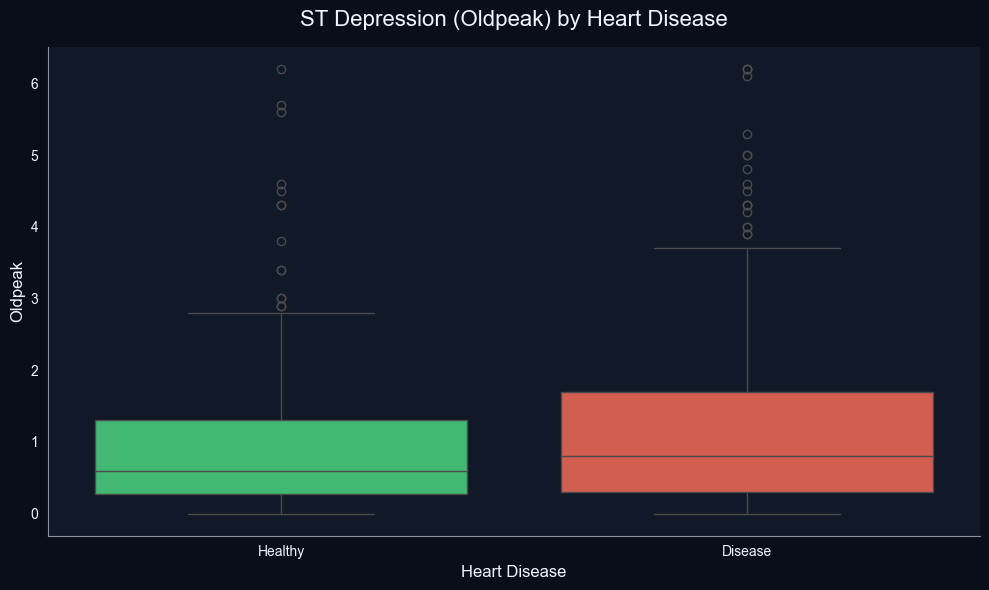

In [21]:
# OLDPEAK DISTRIBUTION BY HEART DISEASE

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Oldpeak",
    hue="HeartDisease",
    palette=[HEALTHY_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

ax.set_title(
    "ST Depression (Oldpeak) by Heart Disease",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Heart Disease")
ax.set_ylabel("Oldpeak")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Healthy", "Disease"])

ax.grid(axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/02_oldpeak_by_disease.png")

plt.show()

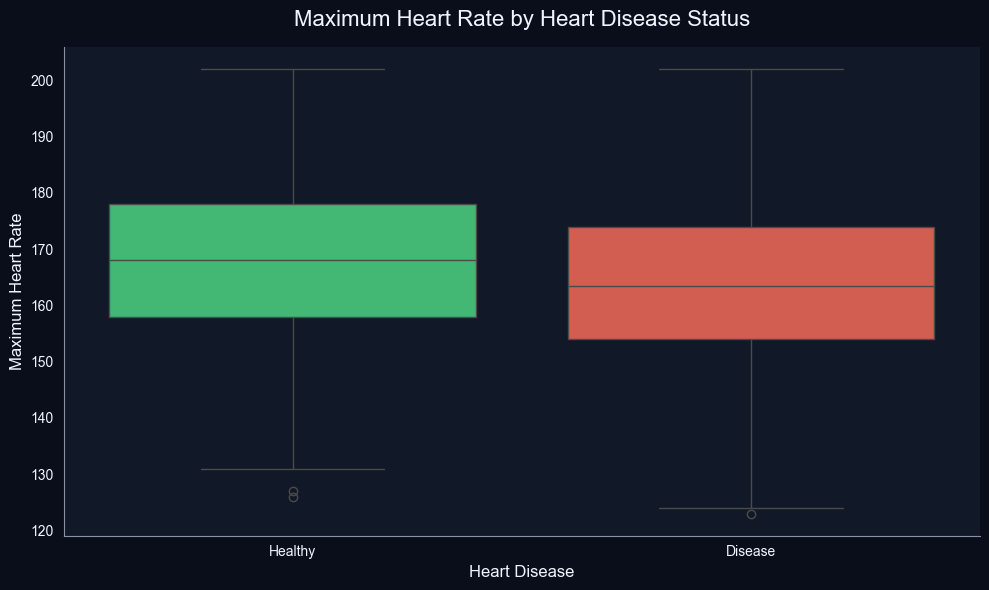

In [22]:
# MAX HEART RATE BY HEART DISEASE

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="HeartDisease",
    y="MaxHR",
    hue="HeartDisease",
    palette=[HEALTHY_COLOR, DISEASE_COLOR],
    legend=False,
    ax=ax
)

ax.set_title(
    "Maximum Heart Rate by Heart Disease Status",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Heart Disease")
ax.set_ylabel("Maximum Heart Rate")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Healthy", "Disease"])

ax.grid(axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../visuals/02_maxhr_by_disease.png")

plt.show()

## Key Clinical Insights

- Asymptomatic chest pain patients exhibited the highest cardiovascular disease prevalence, suggesting that absence of classic symptoms does not imply low cardiac risk.

- Exercise-induced angina showed a strong association with heart disease and appeared to act as a major risk multiplier.

- Diseased patients demonstrated elevated ST depression (Oldpeak), reinforcing its importance as a clinically relevant ECG biomarker.

- Healthy individuals generally achieved higher maximum heart rates, indicating better cardiovascular performance and exercise tolerance.

# Step 5 — Multivariate Analysis

In [23]:
# PREPARE NUMERICAL DATA FOR CORRELATION

correlation_df = df.copy()

# Encode categorical variables
correlation_df["ChestPainType"] = correlation_df["ChestPainType"].map({
    "Typical Angina": 0,
    "Atypical Angina": 1,
    "Non-Anginal Pain": 2,
    "Asymptomatic": 3
})

correlation_df["RestingECG"] = correlation_df["RestingECG"].map({
    "Normal": 0,
    "ST": 1,
    "LVH": 2
})

correlation_df["ST_Slope"] = correlation_df["ST_Slope"].map({
    "Up": 0,
    "Flat": 1,
    "Down": 2
})

# Keep only numerical columns
correlation_df = correlation_df.select_dtypes(include=np.number)

print("Correlation dataset prepared.")

Correlation dataset prepared.


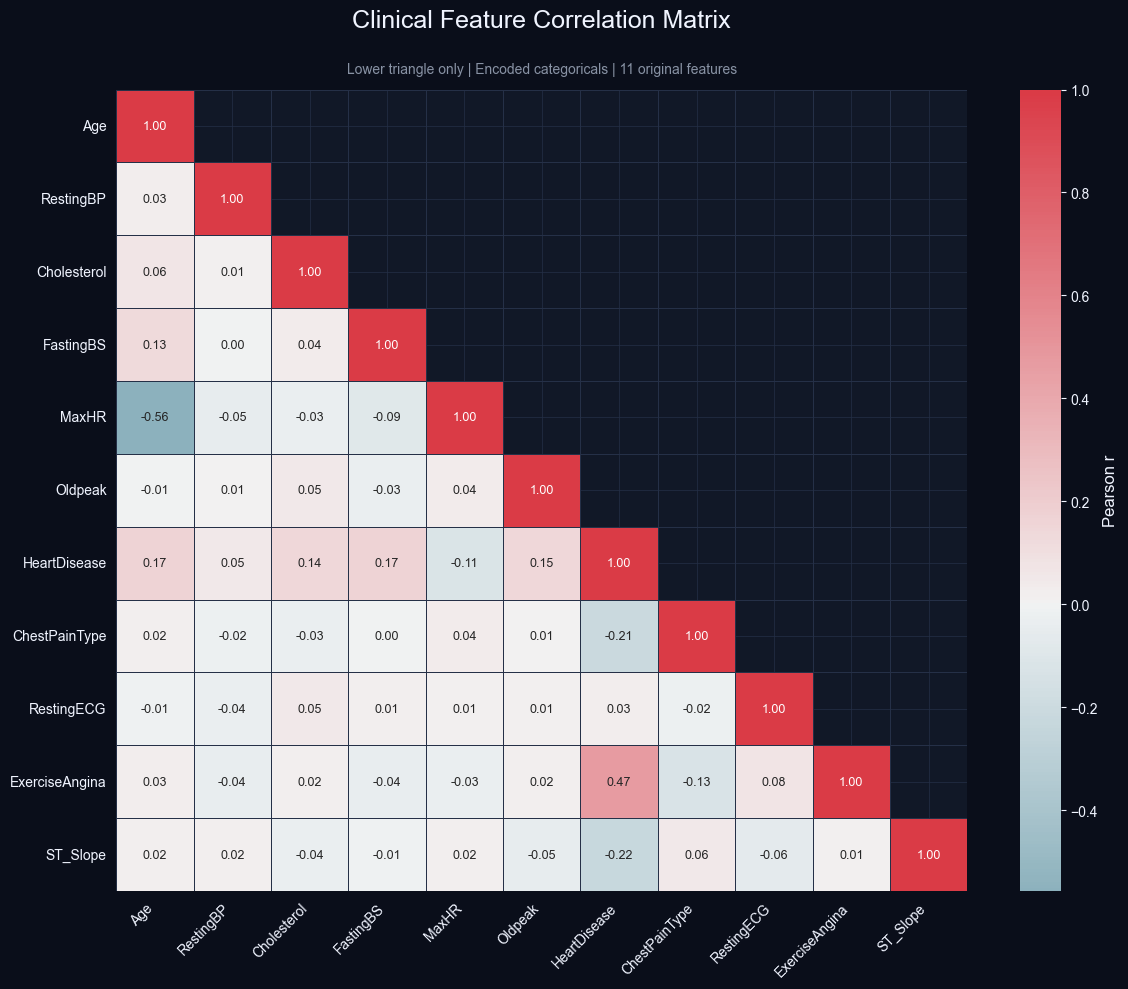

In [31]:
#CLINICAL FEATURE CORRELATION MATRIX

clinical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
                 'Oldpeak', 'HeartDisease', 'ChestPainType', 'RestingECG',
                 'ExerciseAngina', 'ST_Slope']

corr_df = df[clinical_cols].copy()

for col in ['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    corr_df[col] = pd.factorize(corr_df[col])[0]

corr_matrix = corr_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    center=0,
    linewidths=0.5,
    linecolor="#253047",
    annot_kws={"fontsize": 9},       
    cbar_kws={"label": "Pearson r"},
    ax=ax
)

ax.set_title("Clinical Feature Correlation Matrix", fontsize=18, pad=45)
ax.text(0.5, 1.02,
        "Lower triangle only | Encoded categoricals | 11 original features",
        transform=ax.transAxes, ha="center", fontsize=10, color=MUTED_TEXT)

ax.xaxis.label.set_color(TEXT_COLOR)
ax.yaxis.label.set_color(TEXT_COLOR)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("../visuals/03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# FEATURE STRENGTH VS HEART DISEASE

target_correlations = (
    correlation_matrix["HeartDisease"]
    .drop("HeartDisease")
    .sort_values(key=abs, ascending=False)
)

print(target_correlations)

RiskFactorCount           0.549716
ChestPainType             0.476486
ExerciseAngina_encoded    0.471132
ExerciseAngina_Risk       0.471132
ST_Slope_Risk             0.244174
Age_Risk                  0.226693
Oldpeak_Risk              0.169540
Age                       0.168841
FastingBS                 0.167961
BloodSugar_Risk           0.167961
Sex_encoded               0.158626
Oldpeak                   0.148232
Cholesterol               0.144162
Cholesterol_Risk          0.135828
MaxHR                    -0.114255
BP_Risk                   0.084839
RestingBP                 0.053594
ST_Slope                  0.040857
RestingECG                0.028188
Name: HeartDisease, dtype: float64


In [26]:
# STATISTICAL TEST — OLDPEAK

healthy_oldpeak = df[df["HeartDisease"] == 0]["Oldpeak"]

disease_oldpeak = df[df["HeartDisease"] == 1]["Oldpeak"]

u_stat, p_value = stats.mannwhitneyu(
    healthy_oldpeak,
    disease_oldpeak,
    alternative="two-sided"
)

print(f"Mann-Whitney U Statistic: {u_stat:.2f}")
print(f"P-value: {p_value:.10f}")

Mann-Whitney U Statistic: 88735.00
P-value: 0.0000432514


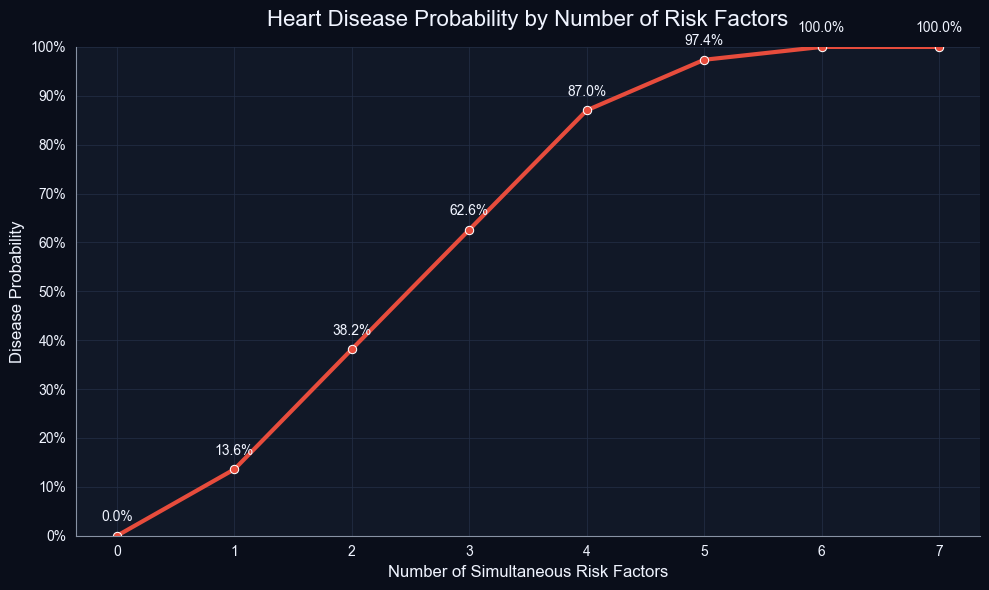

   RiskFactorCount  HeartDisease
0                0      0.000000
1                1      0.136095
2                2      0.381625
3                3      0.626050
4                4      0.870229
5                5      0.973684
6                6      1.000000
7                7      1.000000


In [27]:
# RISK FACTOR COUNT VS DISEASE RATE

risk_profile = (
    df.groupby("RiskFactorCount")["HeartDisease"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=risk_profile,
    x="RiskFactorCount",
    y="HeartDisease",
    marker="o",
    linewidth=3,
    color=DISEASE_COLOR,
    ax=ax
)

ax.set_title(
    "Heart Disease Probability by Number of Risk Factors",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Number of Simultaneous Risk Factors")
ax.set_ylabel("Disease Probability")

ax.set_ylim(0, 1)

yticks = np.arange(0, 1.1, 0.1)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y*100)}%" for y in yticks])

ax.grid(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate points
for x, y in zip(
    risk_profile["RiskFactorCount"],
    risk_profile["HeartDisease"]
):
    ax.text(
        x,
        y + 0.03,
        f"{y:.1%}",
        ha="center",
        fontsize=10,
        color=TEXT_COLOR
    )

plt.tight_layout()

plt.savefig("../visuals/04_risk_profile.png")

plt.show()

print(risk_profile)

# Advanced Analytical Findings

## Strongest Predictors of Heart Disease

- Exercise-induced angina and elevated ST depression (Oldpeak) demonstrated the strongest associations with cardiovascular disease.

- Maximum heart rate showed a negative relationship with disease presence, suggesting reduced cardiovascular performance among affected patients.

- Asymptomatic chest pain patients unexpectedly exhibited the highest disease prevalence, highlighting the importance of silent cardiac risk.

---

## Cumulative Risk Burden

- Heart disease probability increased sharply as clinical risk factors accumulated.

- Patients with 5 or more simultaneous risk indicators demonstrated near-certain disease prevalence.

- This cumulative risk pattern reflects real-world multifactorial cardiovascular disease progression.

# Step 6 — Insights & Clinical Interpretation

# Executive Summary

This project analyzed 918 simulated clinical patient records to identify the strongest predictors of cardiovascular disease using exploratory data analysis and statistical testing.

The analysis combined demographic factors, exercise-related indicators, ECG-derived biomarkers, and cumulative clinical risk profiling to understand how cardiovascular disease prevalence changes across patient populations.

Several clinically meaningful patterns emerged, including strong associations between exercise-induced angina, ST depression (Oldpeak), asymptomatic chest pain presentation, and elevated cardiovascular disease prevalence.

# Key Findings

## 1. Asymptomatic Chest Pain Showed the Highest Disease Risk

Patients categorized as asymptomatic exhibited the highest heart disease prevalence (~78%), demonstrating that absence of classic angina symptoms does not necessarily imply low cardiovascular risk.

---

## 2. Exercise-Induced Angina Was a Major Risk Multiplier

Patients experiencing exercise-induced angina demonstrated substantially elevated disease prevalence, acting as an approximate 2.6x cardiovascular risk multiplier.

---

## 3. ST Depression (Oldpeak) Emerged as the Strongest Continuous Biomarker

Oldpeak values were significantly higher among diseased patients, with Mann-Whitney U testing confirming statistically significant separation between healthy and diseased populations (p < 0.001).

---

## 4. Cardiovascular Risk Escalated Sharply with Accumulating Risk Factors

Patients with multiple simultaneous risk indicators demonstrated dramatically increasing disease prevalence, reaching near-certain probability among high-risk groups.

---

## 5. Male Patients Exhibited Higher Cardiovascular Disease Prevalence

Male patients showed substantially higher disease prevalence than female patients, consistent with broader epidemiological cardiovascular risk patterns.

# Statistical Interpretation

The project combined both visual analysis and statistical validation techniques to strengthen confidence in the observed findings.

Key analytical approaches included:

- Correlation analysis to identify linear relationships between clinical variables and heart disease presence
- Mann-Whitney U testing for non-parametric comparison of Oldpeak distributions
- Cumulative risk aggregation through engineered clinical risk-factor scoring
- Distribution analysis using histograms, boxplots, and grouped prevalence comparisons

These techniques demonstrated that cardiovascular disease risk is strongly multifactorial, with exercise-related indicators and ECG-derived biomarkers emerging as particularly informative predictors.

# Clinical Interpretation

The findings align with several real-world cardiovascular screening principles.

Exercise-induced angina and elevated ST depression are clinically associated with impaired cardiac function and ischemic stress responses, explaining their strong relationship with disease prevalence.

The elevated risk observed among asymptomatic patients highlights an important challenge in cardiovascular medicine: significant disease burden may exist even in the absence of classic symptoms.

Additionally, the cumulative risk-factor escalation pattern reflects the multifactorial nature of cardiovascular disease progression, where combined physiological stressors substantially increase overall disease probability.

# Limitations

- The dataset is simulated and does not represent real patient records.
- Correlation does not imply causation; observed relationships should not be interpreted as direct clinical causality.
- Certain real-world cardiovascular variables such as smoking history, BMI, medication usage, and family history were not included.
- The analysis focuses on exploratory statistical relationships rather than predictive clinical diagnosis.

# Conclusion

This project demonstrated how exploratory data analysis and statistical techniques can uncover clinically meaningful cardiovascular risk patterns from structured healthcare data.

The analysis identified exercise-induced angina, ST depression, asymptomatic chest pain, and cumulative risk burden as strong indicators of cardiovascular disease prevalence.

Beyond technical implementation, the project emphasized analytical storytelling, domain interpretation, and healthcare-oriented reasoning — combining Biomedical Engineering knowledge with practical data analytics workflows.